## Multiple Linear Regression on Insurance Data

### Problem Statement: Predict Insurance Charges from multiple features

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the Dataset
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 1. Explorarory Data Analysis

In [3]:
# Shape of the Dataset
row, col = df.shape
print(f"The dataset has {row} rows and {col} columns")

The dataset has 1338 rows and 7 columns


In [4]:
# What Columns the dataset has and what's their type?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
# Is there any missing data?
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
# Is there any duplicate values?
df.duplicated().sum()

1

In [7]:
# Separate Numerical and Categorical Columns
numerical_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Numerical Columns: {len(numerical_cols)}")
print(f"Categorical Columns: {len(categorical_cols)}")
print(f"Numerical Data: {numerical_cols}")
print(f"Categorical Data: {categorical_cols}")

Numerical Columns: 4
Categorical Columns: 3
Numerical Data: ['age', 'bmi', 'children', 'charges']
Categorical Data: ['sex', 'smoker', 'region']


In [8]:
# Find Numerical columns that are actually Categorical
num_cat_cols = []
for col in numerical_cols:
    unique_count = df[col].nunique()
    if unique_count <= 15:
        unique_vals = sorted(df[col].unique().tolist())
        num_cat_cols.append({
            'column': col,
            'unique_count': unique_count,
            'unique_values': unique_vals
        })
num_cat_cols

[{'column': 'children',
  'unique_count': 6,
  'unique_values': [0, 1, 2, 3, 4, 5]}]

In [9]:
# Summary Statistics for Numerical Columns
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.21,14.05,18.00,27.00,39.00,51.00,64.00
bmi,1338.0,30.66,6.10,15.96,26.30,30.40,34.69,53.13
children,1338.0,1.09,1.21,0.00,0.00,1.00,2.00,5.00
charges,1338.0,13270.42,12110.01,1121.87,4740.29,9382.03,16639.91,63770.43


In [10]:
# Calculate Skewness
skewness = df[numerical_cols].skew().sort_values(ascending=False)
high_skew = skewness[abs(skewness) > 1]
high_skew.round(2)

charges    1.52
dtype: float64

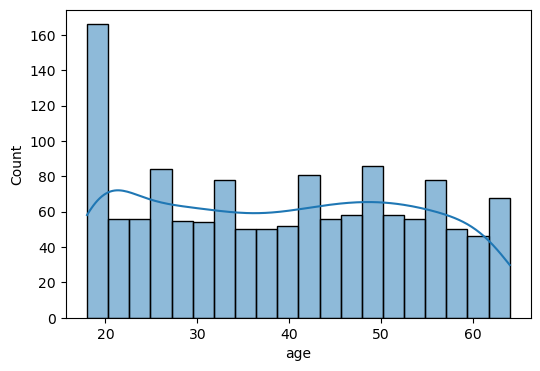

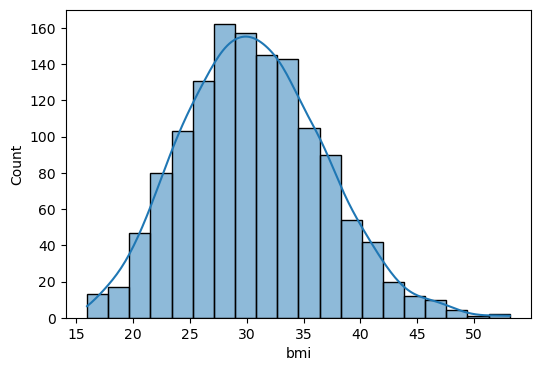

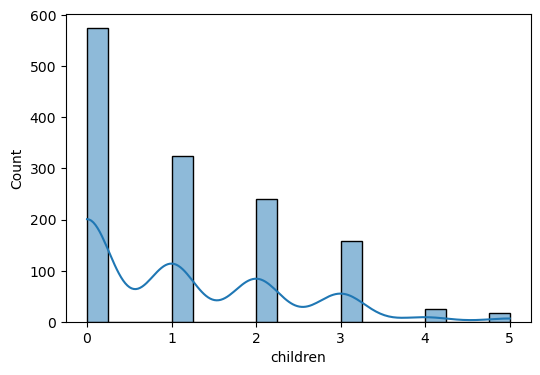

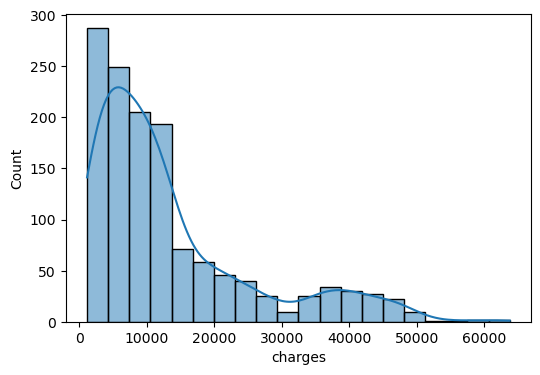

In [11]:
# Visualize the Numerical Data
for col in numerical_cols:
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.histplot(data=df, x=col, kde=True, bins=20)

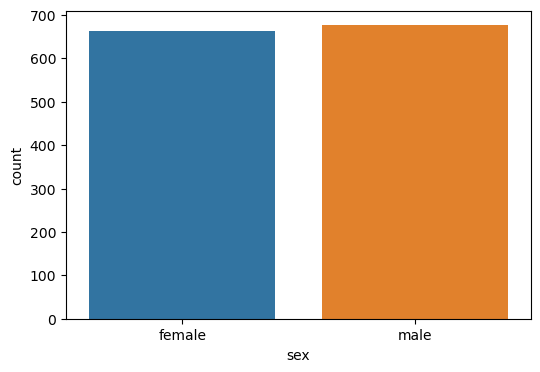

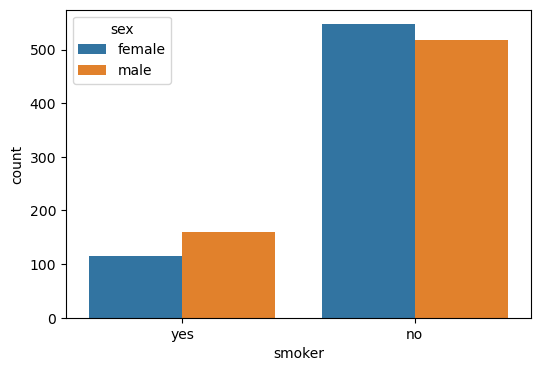

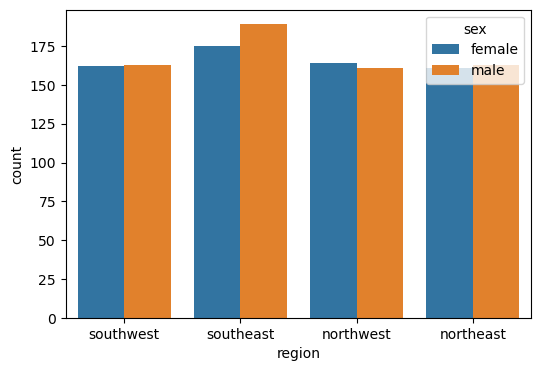

In [12]:
# Visulize the Categorical Data
for col in categorical_cols:
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.countplot(data=df, x=col, hue='sex')

<Axes: xlabel='children', ylabel='count'>

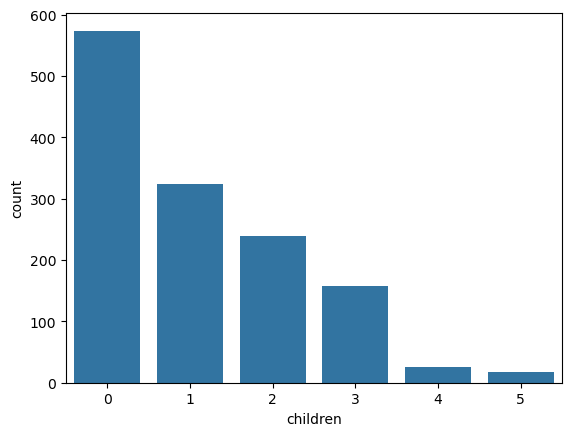

In [13]:
sns.countplot(data=df, x='children')

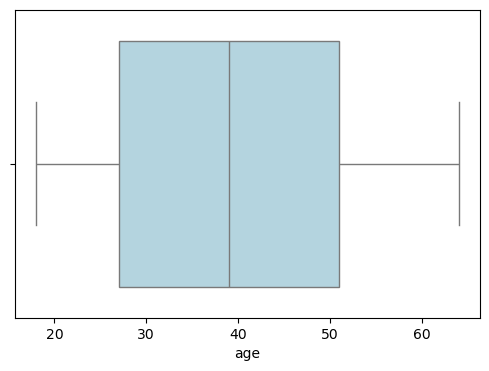

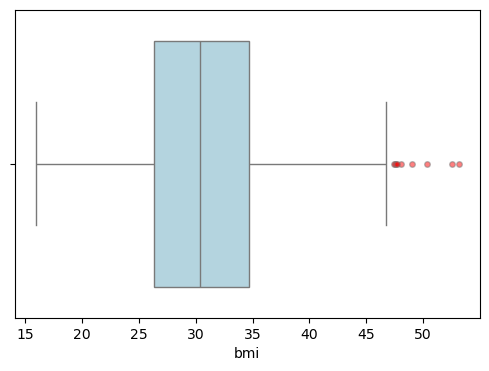

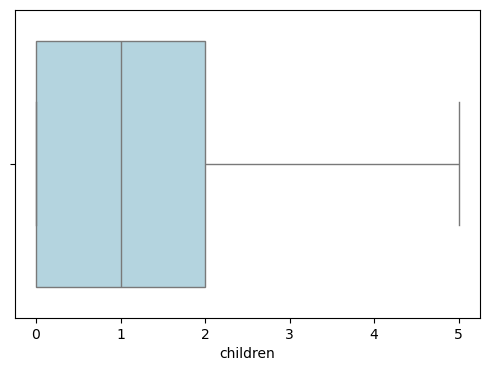

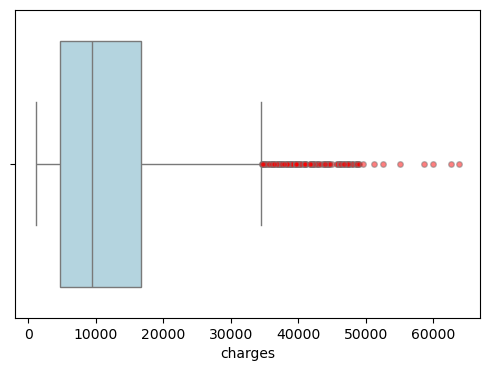

In [14]:
# Boxplot for Numerical Data
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=col, color='lightblue', flierprops = dict(marker= 'o',markerfacecolor= 'red',markersize= 4, alpha= 0.5))

In [15]:
# Correlation of all Numerical features with Target Variable
correlation = df[numerical_cols].corr()['charges'].drop('charges').sort_values(ascending=False)
correlation

age         0.299008
bmi         0.198341
children    0.067998
Name: charges, dtype: float64

Text(0.5, 1.0, 'Correlation Heatmap')

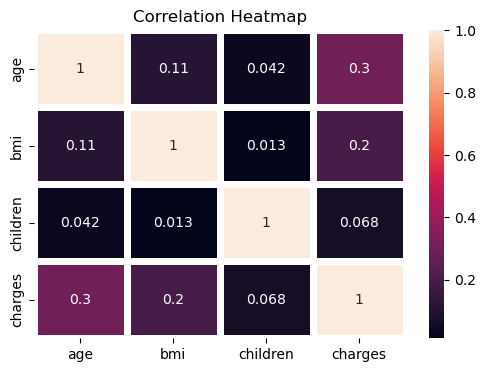

In [16]:
# Correlation Heatmap
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(df[numerical_cols].corr(), annot=True, lw=5)
ax.set_title("Correlation Heatmap")

## 2. Data Cleaning and Feature Engineering

In [17]:
# Remove duplicate values
df.drop_duplicates(inplace=True)
print(f"Shape of the data after removing duplicate values: {df.shape}")

Shape of the data after removing duplicate values: (1337, 7)


In [18]:
# Separate Independent and Dependent Features
X = df.drop(columns='charges', axis=1)
y = df['charges']

In [19]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Training set: 1069 rows
Test set: 268 rows


In [20]:
X_train.head()

,age,sex,bmi,children,smoker,region
1114,23,male,24.510,0,no,northeast
968,21,male,25.745,2,no,northeast
599,52,female,37.525,2,no,northwest
170,63,male,41.470,0,no,southeast
275,47,female,26.600,2,no,northeast


In [21]:
# Binary Encoding
sex_map = {'female': 1, 'male': 0}
smoker_map = {'yes': 1, 'no': 0}

X_train['sex'] = X_train['sex'].map(sex_map)
X_test['sex'] = X_test['sex'].map(sex_map)

X_train['smoker'] = X_train['smoker'].map(smoker_map)
X_test['smoker'] = X_test['smoker'].map(smoker_map)
X_train.head()

,age,sex,bmi,children,smoker,region
1114,23,0,24.510,0,0,northeast
968,21,0,25.745,2,0,northeast
599,52,1,37.525,2,0,northwest
170,63,0,41.470,0,0,southeast
275,47,1,26.600,2,0,northeast


In [22]:
# One-hot Encoding
train_region = pd.get_dummies(X_train['region'], prefix='region', drop_first=True, dtype=int)
test_region = pd.get_dummies(X_test['region'], prefix='region', drop_first=True, dtype=int)

# Join the columns
X_train = pd.concat([X_train, train_region], axis=1)
X_test = pd.concat([X_test, test_region], axis=1)

# Drop the Original Embarked Column
X_train = X_train.drop(columns=['region'])
X_test = X_test.drop(columns=['region'])

X_train.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
1114,23,0,24.510,0,0,0,0,0
968,21,0,25.745,2,0,0,0,0
599,52,1,37.525,2,0,1,0,0
170,63,0,41.470,0,0,0,1,0
275,47,1,26.600,2,0,0,0,0


In [23]:
# Feature Scaling
cols_to_scale = ['age', 'bmi']
scaler = StandardScaler()
scaler.fit(X_train[cols_to_scale])

X_train[cols_to_scale] = scaler.transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("After StandardScaler:")
print(f"Age (mean): {X_train['age'].mean():.4f}, (std): {X_train['age'].std():.4f}")
print(f"BMI (mean): {X_train['bmi'].mean():.4f}, (std): {X_train['bmi'].std():.4f}")

After StandardScaler:
Age (mean): 0.0000, (std): 1.0005
BMI (mean): 0.0000, (std): 1.0005


In [24]:
X_train.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
1114,-1.157680,0,-0.996928,0,0,0,0,0
968,-1.300619,0,-0.792762,2,0,0,0,0
599,0.914926,1,1.154664,2,0,1,0,0
170,1.701087,0,1.806837,0,0,0,1,0
275,0.557580,1,-0.651417,2,0,0,0,0


## 3. Train the Model

In [25]:
# Apply Simple Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Coefficient: {model.coef_[0]}")
print(f"Intercept: {model.intercept_}")

Coefficient: 3472.975553430354
Intercept: 8268.52559756373


## 4. Prediction of Test Data

In [26]:
y_pred = model.predict(X_test)
y_pred

array([ 8.14369388e+03,  5.73711568e+03,  1.43693149e+04,  3.17455136e+04,
        8.96238666e+03,  1.31497224e+04,  3.04467607e+04,  1.45328881e+03,
        1.06330184e+04,  1.13189438e+04,  1.03778536e+04,  3.31184377e+04,
        3.10772527e+04,  1.74119253e+04,  1.08016743e+04,  9.52889964e+03,
        4.16103784e+03,  3.17315373e+04,  3.21938875e+03,  5.22992460e+03,
        3.54979004e+03,  3.02837740e+04,  1.48989509e+04,  3.04569093e+04,
        3.11077668e+04,  5.51196081e+03,  3.55030401e+04,  3.65704810e+04,
        1.14123133e+04,  1.42056990e+04,  6.50234029e+03,  1.27246945e+04,
        3.99806590e+02,  1.20883980e+04,  3.96592069e+04,  1.23395540e+04,
        4.74412279e+03,  3.91903157e+03,  3.08606789e+04,  8.95870663e+03,
        7.05389441e+03,  3.01125636e+04,  3.47804324e+04,  1.22916189e+04,
        7.35739310e+03,  3.42060530e+03,  6.21243471e+03,  8.98345200e+03,
        4.26401828e+03,  9.01992870e+03,  6.60149578e+03,  1.20802337e+04,
        3.12447687e+04,  

In [27]:
y_test

900      8688.85885
1064     5708.86700
1256    11436.73815
298     38746.35510
237      4463.20510
           ...     
534     13831.11520
542     13887.20400
760      3925.75820
1284    47403.88000
1285     8534.67180
Name: charges, Length: 268, dtype: float64

In [28]:
# Calculate MSE, RMSE, MAE
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")

Mean Squared Error: 35478020.6752
Root Mean Squared Error: 5956.3429
Mean Absolute Error: 4177.0456


In [29]:
# Calculate R Square & Adjusted R Square
r2 = r2_score(y_test, y_pred)
print(f"R Square: {r2:.4f}")

adjusted_r2 = 1 - (1-r2)*(len(y_test)-1) / (len(y_test)-X_test.shape[1]-1)
print(f"Adjusted R Square: {adjusted_r2:.4f}")

R Square: 0.8069
Adjusted R Square: 0.8010
